In [19]:
# import the
import pandas as pd 
import numpy as np 
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [8]:
# generate a dataset to use for the analysis
data = {
    "BATCH_ID" : [f'SOAP-{str(i).zfill(3)}' for i in range(1, 51)],
    "pH" : np.random.uniform(6.0, 11.0, 50).round(1),
    "Viscosity_cSt" : np.random.uniform(400, 1200, 50).round(0),
    "Moisture_Pct" : np.random.uniform(8, 20, 50).round(1)
};

df = pd.DataFrame(data)

print(df.head(10))

   BATCH_ID    pH  Viscosity_cSt  Moisture_Pct
0  SOAP-001   9.0          805.0          10.3
1  SOAP-002  10.4          925.0          20.0
2  SOAP-003   7.1          828.0          13.7
3  SOAP-004   6.6         1126.0          10.5
4  SOAP-005  11.0          693.0          14.2
5  SOAP-006  10.4         1195.0          14.4
6  SOAP-007  10.0          904.0          11.5
7  SOAP-008   9.7          780.0          14.7
8  SOAP-009   7.0          418.0          17.4
9  SOAP-010   8.2          804.0          12.9


In [9]:
# created a new column to capture the status of each row
df['Quality_Status'] = np.where(
    (df['pH'] >= 7.0) & (df['pH'] <= 10.0) & (df['Moisture_Pct'] <= 18.0 ), 
    1, # pass  
    0 # fail
)
print(df.head(10))

   BATCH_ID    pH  Viscosity_cSt  Moisture_Pct  Quality_Status
0  SOAP-001   9.0          805.0          10.3               1
1  SOAP-002  10.4          925.0          20.0               0
2  SOAP-003   7.1          828.0          13.7               1
3  SOAP-004   6.6         1126.0          10.5               0
4  SOAP-005  11.0          693.0          14.2               0
5  SOAP-006  10.4         1195.0          14.4               0
6  SOAP-007  10.0          904.0          11.5               1
7  SOAP-008   9.7          780.0          14.7               1
8  SOAP-009   7.0          418.0          17.4               1
9  SOAP-010   8.2          804.0          12.9               1


In [15]:
# creating the x feature and the y target
X = df[['pH','Viscosity_cSt','Moisture_Pct']]
y = df['Quality_Status']

# dividing the data into a training data and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# choosing the model
model = LogisticRegression()

# fit the model
model.fit(X_train, y_train)

# Making prediction on unseen test data
y_pred = model.predict(X_test)

In [16]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[0 9]
 [0 6]]


In [17]:
print(f"True Negatives (Correctly Caught Fails): {cm[0][0]}")
print(f"False Positives (Bad Soap Shipped!):     {cm[0][1]}")
print(f"False Negatives (Good Soap Wasted):     {cm[1][0]}")
print(f"True Positives (Correctly Caught Passes): {cm[1][1]}")

True Negatives (Correctly Caught Fails): 0
False Positives (Bad Soap Shipped!):     9
False Negatives (Good Soap Wasted):     0
True Positives (Correctly Caught Passes): 6


In [18]:
classification_result = classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)'])

print(classification_result)

              precision    recall  f1-score   support

    Fail (0)       0.00      0.00      0.00         9
    Pass (1)       0.40      1.00      0.57         6

    accuracy                           0.40        15
   macro avg       0.20      0.50      0.29        15
weighted avg       0.16      0.40      0.23        15



C:\Users\Khadija Ismail\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Khadija Ismail\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Khadija Ismail\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [21]:
import matplotlib.pyplot as plt 


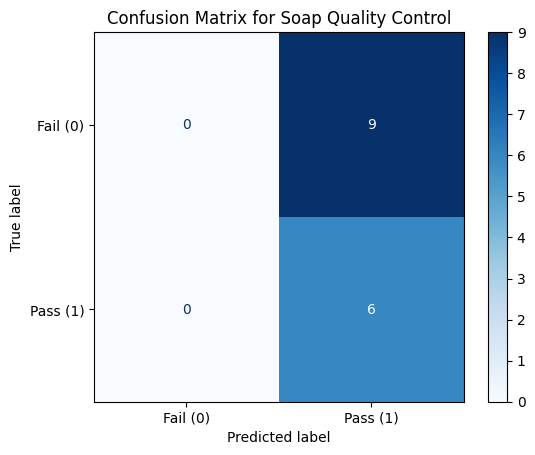

<Figure size 640x480 with 0 Axes>

In [24]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail (0)', 'Pass (1)'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Soap Quality Control')
plt.show()
plt.savefig('confusion_matrix.png')
